In [1]:
import csv
import random
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchaudio
import torchaudio.functional as AF
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm



In [2]:
# Utilities

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def split_number(n: int) -> Tuple[List[int], List[int]]:
    s = str(n).zfill(6)
    digits = [int(c) for c in s]
    return digits[:3], digits[3:]


def thousand_form_class(thousands_digits: List[int]) -> int:
    t = int("".join(map(str, thousands_digits)))
    if t % 10 == 1 and t % 100 != 11:
        return 0  # тысяча
    if 2 <= t % 10 <= 4 and not (12 <= t % 100 <= 14):
        return 1  # тысячи
    return 2  # тысяч


def number_to_target(number_text: str) -> Tuple[List[int], int]:
    n = int(number_text)
    thousands, rest = split_number(n)
    digits6 = thousands + rest
    return digits6, thousand_form_class(thousands)


def digits_to_number(digits6: List[int]) -> int:
    return int("".join(map(str, digits6)))


def levenshtein(a: str, b: str) -> int:
    if a == b:
        return 0
    if len(a) == 0:
        return len(b)
    if len(b) == 0:
        return len(a)

    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        curr = [i]
        for j, cb in enumerate(b, start=1):
            ins = curr[j - 1] + 1
            dele = prev[j] + 1
            sub = prev[j - 1] + (ca != cb)
            curr.append(min(ins, dele, sub))
        prev = curr
    return prev[-1]


def cer_numbers(ref_number: int, hyp_number: int) -> float:
    ref = str(ref_number)
    hyp = str(hyp_number)
    return levenshtein(ref, hyp) / max(len(ref), 1)



In [3]:
# Data

class SpokenNumbersDataset(Dataset):
    def __init__(
        self,
        csv_path: str | Path,
        dataset_root: str | Path,
        target_sample_rate: int = 16_000,
        is_train: bool = False,
        augment_cfg: Optional[Dict[str, Any]] = None,
    ) -> None:
        self.csv_path = Path(csv_path)
        self.dataset_root = Path(dataset_root)
        self.target_sample_rate = target_sample_rate
        self.is_train = is_train

        self.augment_cfg = augment_cfg or {
            "p_speed": 0.8,
            "p_noise": 0.85,
            "p_gain": 0.8,
            "p_shift": 0.6,
            "p_polarity": 0.2,
            "p_drop_chunk": 0.4,
            "p_filter": 0.35,
            "speed_choices": [0.85, 0.93, 1.0, 1.07, 1.15],
            "speed_probs": [0.12, 0.22, 0.32, 0.22, 0.12],
            "speed_min": 0.9,
            "speed_max": 1.1,
            "snr_min": 10.0,
            "snr_max": 30.0,
            "gain_min_db": -6.0,
            "gain_max_db": 6.0,
            "shift_max_s": 0.08,
            "drop_chunk_max_s": 0.10,
        }

        with self.csv_path.open("r", encoding="utf-8", newline="") as f:
            self.rows = list(csv.DictReader(f))

        self._resamplers: Dict[int, torchaudio.transforms.Resample] = {}

    def __len__(self) -> int:
        return len(self.rows)

    def _get_resampler(self, orig_sr: int) -> torchaudio.transforms.Resample:
        if orig_sr not in self._resamplers:
            self._resamplers[orig_sr] = torchaudio.transforms.Resample(orig_sr, self.target_sample_rate)
        return self._resamplers[orig_sr]

    def _random_time_shift(self, waveform: torch.Tensor, sample_rate: int) -> torch.Tensor:
        max_shift = int(self.augment_cfg["shift_max_s"] * sample_rate)
        if max_shift <= 0:
            return waveform
        shift = random.randint(-max_shift, max_shift)
        if shift == 0:
            return waveform
        return torch.roll(waveform, shifts=shift, dims=-1)

    def _drop_random_chunk(self, waveform: torch.Tensor, sample_rate: int) -> torch.Tensor:
        max_len = int(self.augment_cfg["drop_chunk_max_s"] * sample_rate)
        if max_len <= 0 or waveform.numel() < 2:
            return waveform
        cut = random.randint(1, min(max_len, waveform.numel() - 1))
        start = random.randint(0, waveform.numel() - cut)
        waveform = waveform.clone()
        waveform[start : start + cut] = 0.0
        return waveform

    def _random_filter(self, waveform: torch.Tensor, sample_rate: int) -> torch.Tensor:
        # Light random filtering improves robustness to channel variations.
        if random.random() < 0.5:
            cutoff = random.uniform(2500.0, 7000.0)
            waveform = AF.lowpass_biquad(waveform, sample_rate, cutoff)
        else:
            cutoff = random.uniform(80.0, 400.0)
            waveform = AF.highpass_biquad(waveform, sample_rate, cutoff)
        return waveform

    def _augment_waveform(self, waveform: torch.Tensor, sample_rate: int) -> Tuple[torch.Tensor, int]:
        if random.random() < self.augment_cfg["p_speed"]:
            speed_choices = self.augment_cfg.get("speed_choices")
            speed_probs = self.augment_cfg.get("speed_probs")
            if speed_choices is not None and len(speed_choices) > 0:
                factor = random.choices(speed_choices, weights=speed_probs, k=1)[0]
            else:
                # Fallback to legacy continuous sampling if discrete values are not provided.
                factor = random.uniform(self.augment_cfg["speed_min"], self.augment_cfg["speed_max"])

            # Apply speed perturbation as one resample op and keep sample_rate unchanged.
            if abs(factor - 1.0) > 1e-6:
                pseudo_sr = max(1, int(round(sample_rate / factor)))
                waveform = AF.resample(waveform, sample_rate, pseudo_sr)

        if random.random() < self.augment_cfg["p_shift"]:
            waveform = self._random_time_shift(waveform, sample_rate)

        if random.random() < self.augment_cfg["p_noise"]:
            snr_db = random.uniform(self.augment_cfg["snr_min"], self.augment_cfg["snr_max"])
            noise = torch.randn_like(waveform)
            sig_pow = waveform.pow(2).mean().clamp_min(1e-8)
            noise_pow = noise.pow(2).mean().clamp_min(1e-8)
            noise_scale = torch.sqrt(sig_pow / (noise_pow * (10 ** (snr_db / 10.0))))
            waveform = waveform + noise_scale * noise

        if random.random() < self.augment_cfg["p_filter"]:
            waveform = self._random_filter(waveform, sample_rate)

        if random.random() < self.augment_cfg["p_drop_chunk"]:
            waveform = self._drop_random_chunk(waveform, sample_rate)

        if random.random() < self.augment_cfg["p_gain"]:
            gain_db = random.uniform(self.augment_cfg["gain_min_db"], self.augment_cfg["gain_max_db"])
            waveform = waveform * (10 ** (gain_db / 20.0))

        if random.random() < self.augment_cfg["p_polarity"]:
            waveform = -waveform

        waveform = waveform.clamp(-1.0, 1.0)
        return waveform, sample_rate

    def __getitem__(self, index: int) -> Dict[str, Any]:
        row = self.rows[index]
        audio_path = self.dataset_root / row["filename"]

        waveform, sample_rate = torchaudio.load(str(audio_path))
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Normalize all training/inference audio to target SR first.
        if sample_rate != self.target_sample_rate:
            waveform = self._get_resampler(sample_rate)(waveform)
            sample_rate = self.target_sample_rate

        if self.is_train:
            waveform, sample_rate = self._augment_waveform(waveform, sample_rate)

        waveform = waveform.squeeze(0)
        label_text: Optional[str] = None
        if "transcription" in row and row["transcription"] != "":
            label_text = str(row["transcription"])

        return {
            "waveform": waveform,
            "length": waveform.shape[0],
            "filename": row["filename"],
            "label_text": label_text,
        }


def spoken_numbers_collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    waveforms = [x["waveform"] for x in batch]
    lengths = torch.tensor([x["length"] for x in batch], dtype=torch.long)
    return {
        "waveforms": pad_sequence(waveforms, batch_first=True),
        "lengths": lengths,
        "filenames": [x["filename"] for x in batch],
        "label_texts": [x["label_text"] for x in batch],
    }


def create_dataloaders(
    data_root: str | Path,
    batch_size: int = 32,
    num_workers: int = 0,
    pin_memory: bool = False,
    target_sample_rate: int = 16_000,
    augment_cfg: Optional[Dict[str, Any]] = None,
) -> Dict[str, DataLoader]:
    data_root = Path(data_root)

    train_ds = SpokenNumbersDataset(
        csv_path=data_root / "train.csv",
        dataset_root=data_root,
        target_sample_rate=target_sample_rate,
        is_train=True,
        augment_cfg=augment_cfg,
    )
    dev_ds = SpokenNumbersDataset(
        csv_path=data_root / "dev.csv",
        dataset_root=data_root,
        target_sample_rate=target_sample_rate,
        is_train=False,
    )
    test_ds = SpokenNumbersDataset(
        csv_path=data_root / "test.csv",
        dataset_root=data_root,
        target_sample_rate=target_sample_rate,
        is_train=False,
    )

    loader_kwargs = {
        "num_workers": num_workers,
        "pin_memory": pin_memory,
        "collate_fn": spoken_numbers_collate_fn,
    }
    if num_workers > 0:
        loader_kwargs["persistent_workers"] = True

    return {
        "train": DataLoader(train_ds, batch_size=batch_size, shuffle=True, **loader_kwargs),
        "dev": DataLoader(dev_ds, batch_size=batch_size, shuffle=False, **loader_kwargs),
        "test": DataLoader(test_ds, batch_size=batch_size, shuffle=False, **loader_kwargs),
    }



In [4]:
# Model: no global pooling, slot-based decoding over temporal encoder states

class SlotDecoderLayer(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float) -> None:
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, slots: torch.Tensor, memory: torch.Tensor, key_padding_mask: torch.Tensor) -> torch.Tensor:
        h = self.norm1(slots)
        s, _ = self.self_attn(h, h, h)
        slots = slots + self.drop(s)

        h = self.norm2(slots)
        s, _ = self.cross_attn(h, memory, memory, key_padding_mask=key_padding_mask)
        slots = slots + self.drop(s)

        h = self.norm3(slots)
        slots = slots + self.drop(self.ffn(h))
        return slots


class StructuredConformerV2(nn.Module):
    def __init__(
        self,
        n_mels: int = 80,
        n_fft: int = 400,
        hop_length: int = 160,
        d_model: int = 176,
        num_heads: int = 4,
        num_layers: int = 7,
        ffn_dim: int = 448,
        depthwise_conv_kernel_size: int = 31,
        dropout: float = 0.2,
        digit_emb_dim: int = 24,
        decoder_layers: int = 2,
        spec_time_masks: int = 2,
        spec_freq_masks: int = 2,
        spec_time_width: int = 34,
        spec_freq_width: int = 14,
    ) -> None:
        super().__init__()
        self.hop_length = hop_length
        self.spec_time_masks = spec_time_masks
        self.spec_freq_masks = spec_freq_masks

        self.melspec = torchaudio.transforms.MelSpectrogram(
            sample_rate=16_000,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
        )
        self.to_db = torchaudio.transforms.AmplitudeToDB(stype="power")

        self.freq_mask = torchaudio.transforms.FrequencyMasking(freq_mask_param=spec_freq_width, iid_masks=True)
        self.time_mask = torchaudio.transforms.TimeMasking(time_mask_param=spec_time_width, iid_masks=True)

        self.input_norm = nn.LayerNorm(n_mels)
        self.in_proj = nn.Linear(n_mels, d_model)

        self.encoder = torchaudio.models.Conformer(
            input_dim=d_model,
            num_heads=num_heads,
            ffn_dim=ffn_dim,
            num_layers=num_layers,
            depthwise_conv_kernel_size=depthwise_conv_kernel_size,
            dropout=dropout,
            use_group_norm=True,
            convolution_first=False,
        )

        self.num_slots = 7  # 6 digits + 1 form
        self.slot_queries = nn.Parameter(torch.randn(self.num_slots, d_model) * 0.02)
        self.slot_decoder = nn.ModuleList([
            SlotDecoderLayer(d_model=d_model, num_heads=num_heads, dropout=dropout)
            for _ in range(decoder_layers)
        ])

        self.digit_emb = nn.Embedding(10, digit_emb_dim)
        self.digit_heads = nn.ModuleList(
            [nn.Linear(d_model + i * digit_emb_dim, 10) for i in range(6)]
        )
        self.form_head = nn.Linear(d_model + 3 * digit_emb_dim, 3)

    def _apply_specaugment(self, feats: torch.Tensor) -> torch.Tensor:
        out = feats
        for _ in range(self.spec_freq_masks):
            out = self.freq_mask(out)
        for _ in range(self.spec_time_masks):
            out = self.time_mask(out)
        return out

    def _lengths_after_frontend(self, audio_lengths: torch.Tensor, max_frames: int) -> torch.Tensor:
        frame_lengths = (audio_lengths // self.hop_length) + 1
        return torch.clamp(frame_lengths, min=1, max=max_frames)

    def forward(
        self,
        waveforms: torch.Tensor,
        audio_lengths: torch.Tensor,
        target_digits: Optional[torch.Tensor] = None,
        teacher_forcing: bool = False,
    ) -> Dict[str, torch.Tensor]:
        feats = self.melspec(waveforms)
        feats = self.to_db(feats)
        if self.training:
            feats = self._apply_specaugment(feats)

        x = feats.transpose(1, 2)  # [B, T, F]
        x = self.input_norm(x)
        x = self.in_proj(x)

        enc_lengths = self._lengths_after_frontend(audio_lengths, max_frames=x.size(1))
        x, enc_lengths = self.encoder(x, enc_lengths)

        bsz, t_steps, _ = x.shape
        pad_mask = torch.arange(t_steps, device=x.device).unsqueeze(0) >= enc_lengths.unsqueeze(1)

        slots = self.slot_queries.unsqueeze(0).expand(bsz, -1, -1)
        for layer in self.slot_decoder:
            slots = layer(slots, x, key_padding_mask=pad_mask)

        logits_digits: List[torch.Tensor] = []
        emb_context: List[torch.Tensor] = []

        for i in range(6):
            slot_i = slots[:, i, :]
            head_in = torch.cat([slot_i] + emb_context, dim=-1) if emb_context else slot_i
            logits_i = self.digit_heads[i](head_in)
            logits_digits.append(logits_i)

            if teacher_forcing and target_digits is not None:
                d_i = target_digits[:, i]
            else:
                d_i = logits_i.argmax(dim=-1)
            emb_context.append(self.digit_emb(d_i))

        form_slot = slots[:, 6, :]
        form_in = torch.cat([form_slot, emb_context[0], emb_context[1], emb_context[2]], dim=-1)
        logits_form = self.form_head(form_in)

        return {
            "digit_logits": torch.stack(logits_digits, dim=1),
            "form_logits": logits_form,
        }



In [5]:
# Train / validation

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def build_targets(label_texts: List[Optional[str]], device: torch.device) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    valid_idx: List[int] = []
    digits: List[List[int]] = []
    forms: List[int] = []
    for i, text in enumerate(label_texts):
        if text is None:
            continue
        d, f = number_to_target(text)
        valid_idx.append(i)
        digits.append(d)
        forms.append(f)

    if not valid_idx:
        return (
            torch.empty(0, dtype=torch.long, device=device),
            torch.empty((0, 6), dtype=torch.long, device=device),
            torch.empty(0, dtype=torch.long, device=device),
        )

    return (
        torch.tensor(valid_idx, dtype=torch.long, device=device),
        torch.tensor(digits, dtype=torch.long, device=device),
        torch.tensor(forms, dtype=torch.long, device=device),
    )


def decode_digits_from_logits(digit_logits: torch.Tensor) -> List[int]:
    pred_digits = digit_logits.argmax(dim=-1).tolist()
    return [digits_to_number(d) for d in pred_digits]


def compute_losses(
    out: Dict[str, torch.Tensor],
    target_digits: torch.Tensor,
    target_forms: torch.Tensor,
    digit_ce: nn.CrossEntropyLoss,
    form_ce: nn.CrossEntropyLoss,
    digit_weights: torch.Tensor,
    form_loss_weight: float,
) -> Tuple[torch.Tensor, float, float]:
    digit_logits = out["digit_logits"]
    form_logits = out["form_logits"]

    per_pos = []
    for i in range(6):
        l_i = digit_ce(digit_logits[:, i, :], target_digits[:, i])
        per_pos.append(l_i * digit_weights[i])
    digit_loss = torch.stack(per_pos).mean()

    form_loss = form_ce(form_logits, target_forms)
    total_loss = digit_loss + form_loss_weight * form_loss
    return total_loss, float(digit_loss.detach().item()), float(form_loss.detach().item())


def plot_history(history: Dict[str, List[float]]) -> None:
    if len(history.get("epoch", [])) == 0:
        print("History is empty, nothing to plot yet.")
        return

    epochs = history["epoch"]
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["val_cer"], label="val_cer")
    plt.title("CER (numbers)")
    plt.xlabel("Epoch")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_digit_acc"], label="val_digit_acc")
    plt.plot(epochs, history["val_form_acc"], label="val_form_acc")
    plt.title("Aux metrics")
    plt.xlabel("Epoch")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()



In [6]:
# Checkpoint helpers

def save_checkpoint(
    ckpt_path: str | Path,
    model: nn.Module,
    optimizer: Optional[torch.optim.Optimizer],
    scheduler: Optional[torch.optim.lr_scheduler.LRScheduler],
    history: Dict[str, List[float]],
    best_val_cer: float,
) -> Path:
    ckpt_path = Path(ckpt_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
            "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
            "history": history,
            "best_val_cer": best_val_cer,
            "model_class": model.__class__.__name__,
        },
        ckpt_path,
    )
    return ckpt_path


def load_checkpoint(
    ckpt_path: str | Path,
    model: nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[torch.optim.lr_scheduler.LRScheduler] = None,
    device: str | torch.device = "cpu",
) -> Dict[str, Any]:
    ckpt = torch.load(Path(ckpt_path), map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and ckpt.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        for st in optimizer.state.values():
            for k, v in st.items():
                if isinstance(v, torch.Tensor):
                    st[k] = v.to(device)
    if scheduler is not None and ckpt.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    return {
        "history": ckpt.get("history"),
        "best_val_cer": float(ckpt.get("best_val_cer", float("inf"))),
    }


def build_default_scheduler(optimizer: torch.optim.Optimizer) -> torch.optim.lr_scheduler.ReduceLROnPlateau:
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
        threshold=0.001,
        min_lr=1e-6,
    )


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: str | torch.device,
    num_epochs: int,
    tf_ratio: float = 0.3,
    label_smoothing: float = 0.08,
    form_loss_weight: float = 0.35,
    grad_clip: float = 3.0,
    digit_weights: Optional[List[float]] = None,
    scheduler: Optional[torch.optim.lr_scheduler.ReduceLROnPlateau | torch.optim.lr_scheduler.LRScheduler] = None,
    history: Optional[Dict[str, List[float]]] = None,
    best_val_cer: float = float("inf"),
    best_ckpt_path: Optional[str | Path] = None,
    last_ckpt_path: Optional[str | Path] = None,
) -> Tuple[Dict[str, List[float]], float]:
    device = torch.device(device)
    model.to(device)

    if not (0.0 <= tf_ratio <= 1.0):
        raise ValueError(f"tf_ratio must be in [0, 1], got {tf_ratio}")

    if history is None:
        history = {
            "epoch": [],
            "train_loss": [],
            "val_loss": [],
            "val_cer": [],
            "val_digit_acc": [],
            "val_form_acc": [],
            "lr": [],
        }

    if scheduler is None:
        scheduler = build_default_scheduler(optimizer)

    digit_ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    form_ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    dw = digit_weights if digit_weights is not None else [1.2, 1.1, 1.0, 1.0, 1.0, 1.0]
    digit_weights_t = torch.tensor(dw, device=device)

    start_epoch = history["epoch"][-1] + 1 if history["epoch"] else 1

    for epoch in tqdm(range(start_epoch, start_epoch + num_epochs), desc="Epochs"):
        model.train()
        train_loss_sum = 0.0
        train_count = 0

        train_pbar = tqdm(train_loader, desc=f"Train {epoch}", leave=False)
        for batch in train_pbar:
            waveforms = batch["waveforms"].to(device)
            lengths = batch["lengths"].to(device)
            label_texts = batch["label_texts"]

            valid_idx, target_digits, target_forms = build_targets(label_texts, device)
            if valid_idx.numel() == 0:
                continue

            waveforms = waveforms.index_select(0, valid_idx)
            lengths = lengths.index_select(0, valid_idx)

            optimizer.zero_grad(set_to_none=True)
            use_tf = random.random() < tf_ratio
            out = model(waveforms, lengths, target_digits=target_digits, teacher_forcing=use_tf)
            loss, _, _ = compute_losses(
                out,
                target_digits,
                target_forms,
                digit_ce,
                form_ce,
                digit_weights_t,
                form_loss_weight=form_loss_weight,
            )
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            bsz = waveforms.size(0)
            train_loss_sum += loss.item() * bsz
            train_count += bsz
            train_pbar.set_postfix(loss=f"{loss.item():.4f}", tf=f"{int(use_tf)}")

        train_loss = train_loss_sum / max(train_count, 1)

        model.eval()
        val_loss_sum = 0.0
        val_count = 0
        val_cer_sum = 0.0
        val_digit_correct = 0
        val_digit_total = 0
        val_form_correct = 0
        val_form_total = 0

        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f"Val {epoch}", leave=False)
            for batch in val_pbar:
                waveforms = batch["waveforms"].to(device)
                lengths = batch["lengths"].to(device)
                label_texts = batch["label_texts"]

                valid_idx, target_digits, target_forms = build_targets(label_texts, device)
                if valid_idx.numel() == 0:
                    continue

                waveforms = waveforms.index_select(0, valid_idx)
                lengths = lengths.index_select(0, valid_idx)

                out_tf = model(waveforms, lengths, target_digits=target_digits, teacher_forcing=True)
                loss, _, _ = compute_losses(
                    out_tf,
                    target_digits,
                    target_forms,
                    digit_ce,
                    form_ce,
                    digit_weights_t,
                    form_loss_weight=form_loss_weight,
                )

                bsz = waveforms.size(0)
                val_loss_sum += loss.item() * bsz
                val_count += bsz

                out = model(waveforms, lengths, target_digits=None, teacher_forcing=False)
                pred_digits = out["digit_logits"].argmax(dim=-1)
                pred_forms = out["form_logits"].argmax(dim=-1)

                val_digit_correct += (pred_digits == target_digits).sum().item()
                val_digit_total += target_digits.numel()
                val_form_correct += (pred_forms == target_forms).sum().item()
                val_form_total += target_forms.numel()

                pred_numbers = decode_digits_from_logits(out["digit_logits"])
                target_numbers = [int(label_texts[i]) for i in valid_idx.tolist()]
                for tgt, pred in zip(target_numbers, pred_numbers):
                    val_cer_sum += cer_numbers(tgt, pred)

        val_loss = val_loss_sum / max(val_count, 1)
        val_cer = val_cer_sum / max(val_count, 1)
        val_digit_acc = val_digit_correct / max(val_digit_total, 1)
        val_form_acc = val_form_correct / max(val_form_total, 1)

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_cer)
        else:
            scheduler.step()
        lr_now = optimizer.param_groups[0]["lr"]

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_cer"].append(val_cer)
        history["val_digit_acc"].append(val_digit_acc)
        history["val_form_acc"].append(val_form_acc)
        history["lr"].append(lr_now)

        if val_cer < best_val_cer:
            best_val_cer = val_cer
            if best_ckpt_path is not None:
                save_checkpoint(best_ckpt_path, model, optimizer, scheduler, history, best_val_cer)

        if last_ckpt_path is not None:
            save_checkpoint(last_ckpt_path, model, optimizer, scheduler, history, best_val_cer)

        print(
            f"Epoch {epoch}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"val_cer={val_cer:.4f} | val_digit_acc={val_digit_acc:.4f} | "
            f"val_form_acc={val_form_acc:.4f} | lr={lr_now:.2e} | best_val_cer={best_val_cer:.4f}"
        )

    plot_history(history)
    return history, best_val_cer



In [15]:
# Train cell (all key regularization params are here)
set_seed(42)

PROJECT_DIR = Path.cwd()
DATA_ROOT = PROJECT_DIR / "asr-2026-spoken-numbers-recognition-challenge"
CKPT_DIR = PROJECT_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 5 эпох с tf_ratio 0.7, затем еще 30 с tf 0.2
# 30 эпох с tf_ratio 0.2 и reduce plateau
# 20 эпох с tf ratio 0 и cosine scheduler
TRAIN_CFG = {
    "batch_size": 16,
    "num_workers": 0,
    "learning_rate":  1e-5,
    "weight_decay": 1e-2,
    "epochs": 10,
    "tf_ratio": 0,
    "label_smoothing": 0.0,
    "form_loss_weight": 0.0,
    "grad_clip": 1.0,
    "digit_weights": [1.2, 1.1, 1.0, 1.0, 1.0, 1.0],
}

AUGMENT_CFG = {
    "p_speed": 0.,
    "p_noise": 0.4,
    "p_gain": 0.5,
    "p_shift": 0.2,
    "p_polarity": 0.,
    "p_drop_chunk": 0.,
    "p_filter": 0.0,
    "snr_min": 20.0,
    "snr_max": 40.0,
    "gain_min_db": -3.0,
    "gain_max_db": 3.0,
    "shift_max_s": 0.05,
    "drop_chunk_max_s": 0.10,
}


MODEL_CFG = {
    "d_model": 176,
    "num_heads": 4,
    "num_layers": 7,
    "ffn_dim": 448,
    "dropout": 0.20,
    "digit_emb_dim": 24,
    "decoder_layers": 2,
    "spec_time_masks": 2,
    "spec_freq_masks": 2,
    "spec_time_width": 34,
    "spec_freq_width": 14,
}

loaders = create_dataloaders(
    data_root=DATA_ROOT,
    batch_size=TRAIN_CFG["batch_size"],
    num_workers=TRAIN_CFG["num_workers"],
    pin_memory=(DEVICE == "cuda"),
    augment_cfg=AUGMENT_CFG,
)

model = globals().get("model", None)
optimizer = globals().get("optimizer", None)
scheduler = globals().get("scheduler", None)
history = globals().get("history", None)
best_val_cer = globals().get("best_val_cer", float("inf"))

if model is None or not isinstance(model, StructuredConformerV2):
    model = StructuredConformerV2(**MODEL_CFG)
if optimizer is None:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=TRAIN_CFG["learning_rate"],
        weight_decay=TRAIN_CFG["weight_decay"],
    )
if scheduler is None:
    scheduler = build_default_scheduler(optimizer)
if history is None:
    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "val_cer": [],
        "val_digit_acc": [],
        "val_form_acc": [],
        "lr": [],
    }
if best_val_cer is None:
    best_val_cer = float("inf")

num_params = count_parameters(model)
print(f"Device: {DEVICE}")
print(f"Trainable params: {num_params:,}")
if num_params > 5_000_000:
    raise ValueError(f"Model has {num_params:,} params, expected <= 5,000,000")

BEST_CKPT_PATH = CKPT_DIR / "conformer2_best.pt"
LAST_CKPT_PATH = CKPT_DIR / "conformer2_last.pt"

Device: cuda
Trainable params: 4,825,911


In [16]:
state = load_checkpoint(r'C:\Users\tosha\PycharmProjects\SpeechCourse\project1\checkpoints\conformer2_best_053.pt', model, optimizer, scheduler, device=DEVICE)
history = state["history"]
best_val_cer = state["best_val_cer"]

In [17]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=TRAIN_CFG["learning_rate"],
    weight_decay=TRAIN_CFG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    threshold=0.001,
    min_lr=1e-7,
)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train 51:   0%|          | 0/785 [00:00<?, ?it/s]

Val 51:   0%|          | 0/142 [00:00<?, ?it/s]

Epoch 51: train_loss=0.0287 | val_loss=0.2529 | val_cer=0.0553 | val_digit_acc=0.9467 | val_form_acc=0.9823 | lr=1.00e-05 | best_val_cer=0.0538


Train 52:   0%|          | 0/785 [00:00<?, ?it/s]

...

Val 59:   0%|          | 0/142 [00:00<?, ?it/s]

Epoch 59: train_loss=0.0128 | val_loss=0.3193 | val_cer=0.0565 | val_digit_acc=0.9455 | val_form_acc=0.9854 | lr=2.50e-06 | best_val_cer=0.0538


Train 60:   0%|          | 0/785 [00:00<?, ?it/s]

Val 60:   0%|          | 0/142 [00:00<?, ?it/s]

Epoch 60: train_loss=0.0139 | val_loss=0.3264 | val_cer=0.0570 | val_digit_acc=0.9451 | val_form_acc=0.9854 | lr=2.50e-06 | best_val_cer=0.0538


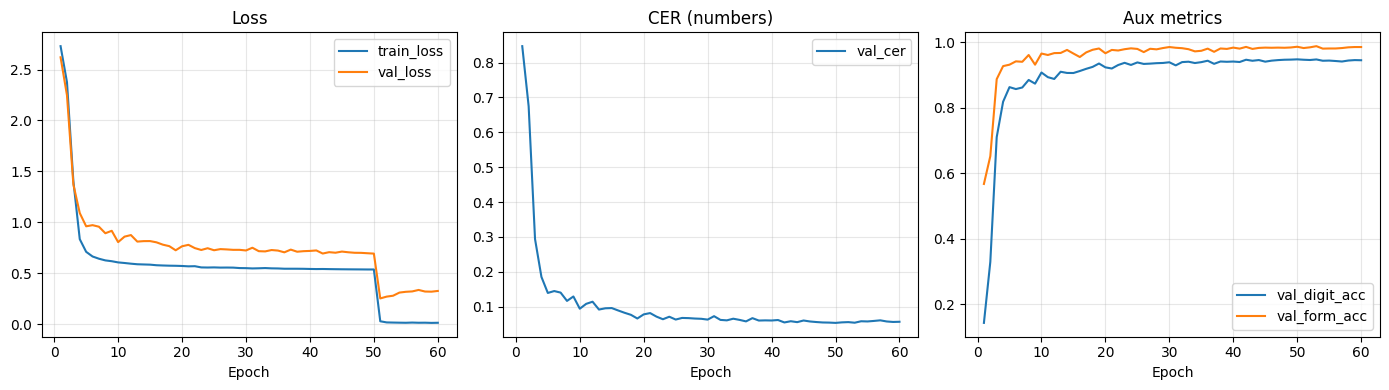

In [18]:
history, best_val_cer = train_model(
    model=model,
    train_loader=loaders["train"],
    val_loader=loaders["dev"],
    optimizer=optimizer,
    device=DEVICE,
    num_epochs=TRAIN_CFG["epochs"],
    tf_ratio=TRAIN_CFG["tf_ratio"],
    label_smoothing=TRAIN_CFG["label_smoothing"],
    form_loss_weight=TRAIN_CFG["form_loss_weight"],
    grad_clip=TRAIN_CFG["grad_clip"],
    digit_weights=TRAIN_CFG["digit_weights"],
    scheduler=scheduler,
    history=history,
    best_val_cer=best_val_cer,
    best_ckpt_path=BEST_CKPT_PATH,
    last_ckpt_path=LAST_CKPT_PATH,
)

In [ ]:
# Resume from checkpoint (optional)
# state = load_checkpoint(LAST_CKPT_PATH, model, optimizer, scheduler, device=DEVICE)
# history = state["history"]
# best_val_cer = state["best_val_cer"]

In [20]:
# Submission

def make_submission(
    model: nn.Module,
    test_loader: DataLoader,
    output_csv_path: str | Path,
    device: str | torch.device,
) -> Path:
    device = torch.device(device)
    model.to(device)
    model.eval()

    filenames: List[str] = []
    predictions: List[str] = []

    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Submission")
        for batch in pbar:
            waveforms = batch["waveforms"].to(device)
            lengths = batch["lengths"].to(device)
            batch_filenames = batch["filenames"]

            out = model(waveforms, lengths, target_digits=None, teacher_forcing=False)
            pred_numbers = decode_digits_from_logits(out["digit_logits"])

            for n in pred_numbers:
                n = min(max(n, 1000), 999999)
                predictions.append(str(n))
            filenames.extend(batch_filenames)

    output_csv_path = Path(output_csv_path)
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)

    with output_csv_path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["filename", "transcription"])
        for fn, pred in zip(filenames, predictions):
            writer.writerow([fn, pred])

    print(f"Saved submission: {output_csv_path}")
    return output_csv_path


def good_resample_rate(orig_sr: int, speed: float, divisor: int = 100) -> int:
    """Округляем до кратного divisor чтобы gcd был большим."""
    raw = orig_sr / speed
    return max(divisor, round(raw / divisor) * divisor)


def make_submission_tta(
    model: nn.Module,
    test_loader: DataLoader,
    output_csv_path: str | Path,
    device: str | torch.device,
    speed_factors: Optional[List[float]] = None,
) -> Path:
    if speed_factors is None:
        speed_factors = [0.93, 0.97, 1.0, 1.03, 1.07]

    device = torch.device(device)
    model.to(device)
    model.eval()

    filenames: List[str] = []
    all_pass_logits: List[List[torch.Tensor]] = []  # [n_passes][n_batches] -> Tensor [B, 6, 10]

    for speed in speed_factors:
        pass_logits: List[torch.Tensor] = []

        with torch.no_grad():
            pbar = tqdm(test_loader, desc=f"TTA speed={speed:.2f}")
            for batch in pbar:
                waveforms = batch["waveforms"].to(device)
                lengths = batch["lengths"].to(device)

                if abs(speed - 1.0) > 1e-6:
                    pseudo_sr = good_resample_rate(16_000, speed, divisor=100)
                    orig_T = waveforms.shape[-1]
                    waveforms = AF.resample(waveforms, 16_000, pseudo_sr)
                    new_T = waveforms.shape[-1]
                    lengths = (lengths.float() * new_T / orig_T).ceil().long().clamp(min=1, max=new_T)

                out = model(waveforms, lengths, target_digits=None, teacher_forcing=False)
                pass_logits.append(out["digit_logits"].softmax(dim=-1).cpu())

                if speed == speed_factors[0]:
                    filenames.extend(batch["filenames"])

        all_pass_logits.append(pass_logits)

    # Усредняем вероятности по всем passes
    n_batches = len(all_pass_logits[0])
    predictions: List[str] = []
    for b in range(n_batches):
        avg = torch.stack([all_pass_logits[p][b] for p in range(len(speed_factors))]).mean(0)
        pred_numbers = decode_digits_from_logits(avg)
        for n in pred_numbers:
            n = min(max(n, 1000), 999999)
            predictions.append(str(n))

    output_csv_path = Path(output_csv_path)
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)

    with output_csv_path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["filename", "transcription"])
        for fn, pred in zip(filenames, predictions):
            writer.writerow([fn, pred])

    print(f"Saved submission: {output_csv_path}")
    return output_csv_path

In [22]:
submission_path = make_submission_tta(
    model=model,
    test_loader=loaders["test"],
    output_csv_path=PROJECT_DIR / "submission_conformer2_ftb_ftl_tta.csv",
    device=DEVICE,
)

with submission_path.open("r", encoding="utf-8") as f:
    for _ in range(5):
        print(f.readline().strip())

SyntaxError: unterminated string literal (detected at line 11) (3217976709.py, line 11)